In [1]:
import sys
import os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
pd.set_option('display.max_rows', None)

In [3]:
anime_raw = pd.read_csv(r'data/anime.csv')
animelist_raw = pd.read_csv(r'data/animelist.csv')

In [4]:
anime = anime_raw.copy()
animelist = animelist_raw.sample(n=100000, replace=True, random_state=42).copy()


In [5]:
animelist_raw.head()

,user_id,anime_id,rating,watching_status,watched_episodes
0,0,67,9,1,1
1,0,6702,7,1,4
2,0,242,10,1,4
3,0,4898,0,1,1
4,0,21,10,1,0


In [6]:
anime.columns

Index(['MAL_ID', 'Name', 'Score', 'Genres', 'English name', 'Japanese name',
       'Type', 'Episodes', 'Aired', 'Premiered', 'Producers', 'Licensors',
       'Studios', 'Source', 'Duration', 'Rating', 'Ranked', 'Popularity',
       'Members', 'Favorites', 'Watching', 'Completed', 'On-Hold', 'Dropped',
       'Plan to Watch', 'Score-10', 'Score-9', 'Score-8', 'Score-7', 'Score-6',
       'Score-5', 'Score-4', 'Score-3', 'Score-2', 'Score-1'],
      dtype='object')

In [7]:
animelist.columns

Index(['user_id', 'anime_id', 'rating', 'watching_status', 'watched_episodes'], dtype='object')

In [8]:
anime.columns = (
    anime.columns
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("-", "_")
)
anime.columns

Index(['mal_id', 'name', 'score', 'genres', 'english_name', 'japanese_name',
       'type', 'episodes', 'aired', 'premiered', 'producers', 'licensors',
       'studios', 'source', 'duration', 'rating', 'ranked', 'popularity',
       'members', 'favorites', 'watching', 'completed', 'on_hold', 'dropped',
       'plan_to_watch', 'score_10', 'score_9', 'score_8', 'score_7', 'score_6',
       'score_5', 'score_4', 'score_3', 'score_2', 'score_1'],
      dtype='object')

In [9]:
anime_filtered = anime[['mal_id', 'name', 'score', 'genres', 'english_name', 'type', 'episodes', 'aired', 'premiered', 'producers', 'licensors', 'studios', 'source', 'duration', 'rating', 'ranked', 'popularity', 'members', 'favorites', 'watching', 'completed', 'on_hold', 'dropped', 'plan_to_watch', 'score_10', 'score_9', 'score_8', 'score_7', 'score_6', 'score_5', 'score_4', 'score_3', 'score_2', 'score_1']].rename(columns={'mal_id': 'anime_id'})

In [10]:
anime_filtered.columns

Index(['anime_id', 'name', 'score', 'genres', 'english_name', 'type',
       'episodes', 'aired', 'premiered', 'producers', 'licensors', 'studios',
       'source', 'duration', 'rating', 'ranked', 'popularity', 'members',
       'favorites', 'watching', 'completed', 'on_hold', 'dropped',
       'plan_to_watch', 'score_10', 'score_9', 'score_8', 'score_7', 'score_6',
       'score_5', 'score_4', 'score_3', 'score_2', 'score_1'],
      dtype='object')

In [11]:
anime_full = pd.merge(anime_filtered, animelist, on='anime_id', how='inner')

In [12]:
anime_full.columns

Index(['anime_id', 'name', 'score', 'genres', 'english_name', 'type',
       'episodes', 'aired', 'premiered', 'producers', 'licensors', 'studios',
       'source', 'duration', 'rating_x', 'ranked', 'popularity', 'members',
       'favorites', 'watching', 'completed', 'on_hold', 'dropped',
       'plan_to_watch', 'score_10', 'score_9', 'score_8', 'score_7', 'score_6',
       'score_5', 'score_4', 'score_3', 'score_2', 'score_1', 'user_id',
       'rating_y', 'watching_status', 'watched_episodes'],
      dtype='object')

In [13]:
anime_full.dtypes

anime_id             int64
name                object
score               object
genres              object
english_name        object
type                object
episodes            object
aired               object
premiered           object
producers           object
licensors           object
studios             object
source              object
duration            object
rating_x            object
ranked              object
popularity           int64
members              int64
favorites            int64
watching             int64
completed            int64
on_hold              int64
dropped              int64
plan_to_watch        int64
score_10            object
score_9             object
score_8             object
score_7             object
score_6             object
score_5             object
score_4             object
score_3             object
score_2             object
score_1             object
user_id              int64
rating_y             int64
watching_status      int64
w

In [14]:
def format_numbers(df, threshold=0.7):
    df_formatted = df.copy()

    df_formatted = df_formatted.replace(
        r'^\s*(unknown|Unknown)\s*$',
        np.nan,
        regex=True
    )

    for col in df_formatted.columns:
        series = df_formatted[col]

        # Skip already numeric columns
        if pd.api.types.is_numeric_dtype(series):
            df_formatted[col] = series.astype(float)
            continue

        # Try converting
        converted = pd.to_numeric(series, errors="coerce")

        total_non_null = series.notna().sum()
        numeric_count = converted.notna().sum()

        # Only convert if MOST values are numeric
        if total_non_null > 0 and (numeric_count / total_non_null) >= threshold:
            df_formatted[col] = converted.astype(float)

    return df_formatted

In [15]:
anime_formatted = format_numbers(anime_full)
anime_formatted.columns

Index(['anime_id', 'name', 'score', 'genres', 'english_name', 'type',
       'episodes', 'aired', 'premiered', 'producers', 'licensors', 'studios',
       'source', 'duration', 'rating_x', 'ranked', 'popularity', 'members',
       'favorites', 'watching', 'completed', 'on_hold', 'dropped',
       'plan_to_watch', 'score_10', 'score_9', 'score_8', 'score_7', 'score_6',
       'score_5', 'score_4', 'score_3', 'score_2', 'score_1', 'user_id',
       'rating_y', 'watching_status', 'watched_episodes'],
      dtype='object')

In [22]:
test = anime_formatted.groupby('episodes')['name'].first().reset_index().sort_values('episodes', ascending=False)
test.head(20)

,episodes,name
162,1787.0,Doraemon (1979)
161,1471.0,Manga Nippon Mukashibanashi (1976)
160,694.0,Ninja Hattori-kun
159,526.0,Perman (1983)
158,500.0,Naruto: Shippuuden
157,373.0,Kochira Katsushikaku Kameari Kouenmae Hashutsujo
156,366.0,Bleach
155,365.0,Charady no Joke na Mainichi
154,358.0,Keroro Gunsou
153,305.0,Cookin' Idol Ai! Mai! Main!


In [ ]:
test['episodes'].unique()

array([ 26.,  24.,  74., 220., 178.,  22.,  69.,  25.,  94.,  12.,  23.,
        13.,  43.,  50.,  47.,  51.,  49.,  39.,  52.,  75.,  62.,  14.,
        45.,  64., 101.,  27., 161., 153.,  70.,  42.,  11., 167., 150.,
        78., 366.,   9.,  38.,  48.,   4.,  10.,  76.,  40., 112.,  20.,
       224., 180., 296., 358., 276.,  46.,  54.,   6.,  16., 291.,  29.,
       201.,  44., 109.,  34.,  36.,  32.,  19.,   5., 195.,  96., 103.,
       102.,  37., 192., 203.,  41.,  56., 500., 172.,  65.,  35.,  92.,
       100.,  31., 193.,  91., 154.,  15., 175.,  30.,  84.,  60.,  86.,
        73., 147.,  21., 148.,   3.,  99., 214.,  93., 131.,   8.,  89.,
       120., 146., 170.,   7.,  18.])

In [ ]:
anime_formatted.dtypes

anime_id            float64
name                 object
score               float64
genres               object
english_name         object
type                 object
episodes            float64
aired                object
premiered            object
producers            object
licensors            object
studios              object
source               object
duration             object
rating_x             object
ranked              float64
popularity          float64
members             float64
favorites           float64
watching            float64
completed           float64
on_hold             float64
dropped             float64
plan_to_watch       float64
score_10            float64
score_9             float64
score_8             float64
score_7             float64
score_6             float64
score_5             float64
score_4             float64
score_3             float64
score_2             float64
score_1             float64
user_id             float64
rating_y            

In [ ]:
anime_formatted.head()

,anime_id,name,score,genres,english_name,type,episodes,aired,premiered,producers,...,score_6,score_5,score_4,score_3,score_2,score_1,user_id,rating_y,watching_status,watched_episodes
0,1.0,Cowboy Bebop,8.78,"Action, Adventure, Comedy, Drama, Sci-Fi, Space",Cowboy Bebop,TV,26.0,"Apr 3, 1998 to Apr 24, 1999",Spring 1998,Bandai Visual,...,20688.0,8904.0,3184.0,1357.0,741.0,1580.0,20764.0,8.0,2.0,26.0
1,1.0,Cowboy Bebop,8.78,"Action, Adventure, Comedy, Drama, Sci-Fi, Space",Cowboy Bebop,TV,26.0,"Apr 3, 1998 to Apr 24, 1999",Spring 1998,Bandai Visual,...,20688.0,8904.0,3184.0,1357.0,741.0,1580.0,127655.0,10.0,2.0,26.0
2,1.0,Cowboy Bebop,8.78,"Action, Adventure, Comedy, Drama, Sci-Fi, Space",Cowboy Bebop,TV,26.0,"Apr 3, 1998 to Apr 24, 1999",Spring 1998,Bandai Visual,...,20688.0,8904.0,3184.0,1357.0,741.0,1580.0,141660.0,8.0,2.0,26.0
3,1.0,Cowboy Bebop,8.78,"Action, Adventure, Comedy, Drama, Sci-Fi, Space",Cowboy Bebop,TV,26.0,"Apr 3, 1998 to Apr 24, 1999",Spring 1998,Bandai Visual,...,20688.0,8904.0,3184.0,1357.0,741.0,1580.0,76003.0,0.0,6.0,0.0
4,1.0,Cowboy Bebop,8.78,"Action, Adventure, Comedy, Drama, Sci-Fi, Space",Cowboy Bebop,TV,26.0,"Apr 3, 1998 to Apr 24, 1999",Spring 1998,Bandai Visual,...,20688.0,8904.0,3184.0,1357.0,741.0,1580.0,34395.0,0.0,6.0,0.0


In [ ]:
anime_formatted.dtypes

anime_id            float64
name                 object
score               float64
genres               object
english_name         object
type                 object
episodes            float64
aired                object
premiered            object
producers            object
licensors            object
studios              object
source               object
duration             object
rating_x             object
ranked              float64
popularity          float64
members             float64
favorites           float64
watching            float64
completed           float64
on_hold             float64
dropped             float64
plan_to_watch       float64
score_10            float64
score_9             float64
score_8             float64
score_7             float64
score_6             float64
score_5             float64
score_4             float64
score_3             float64
score_2             float64
score_1             float64
user_id             float64
rating_y            

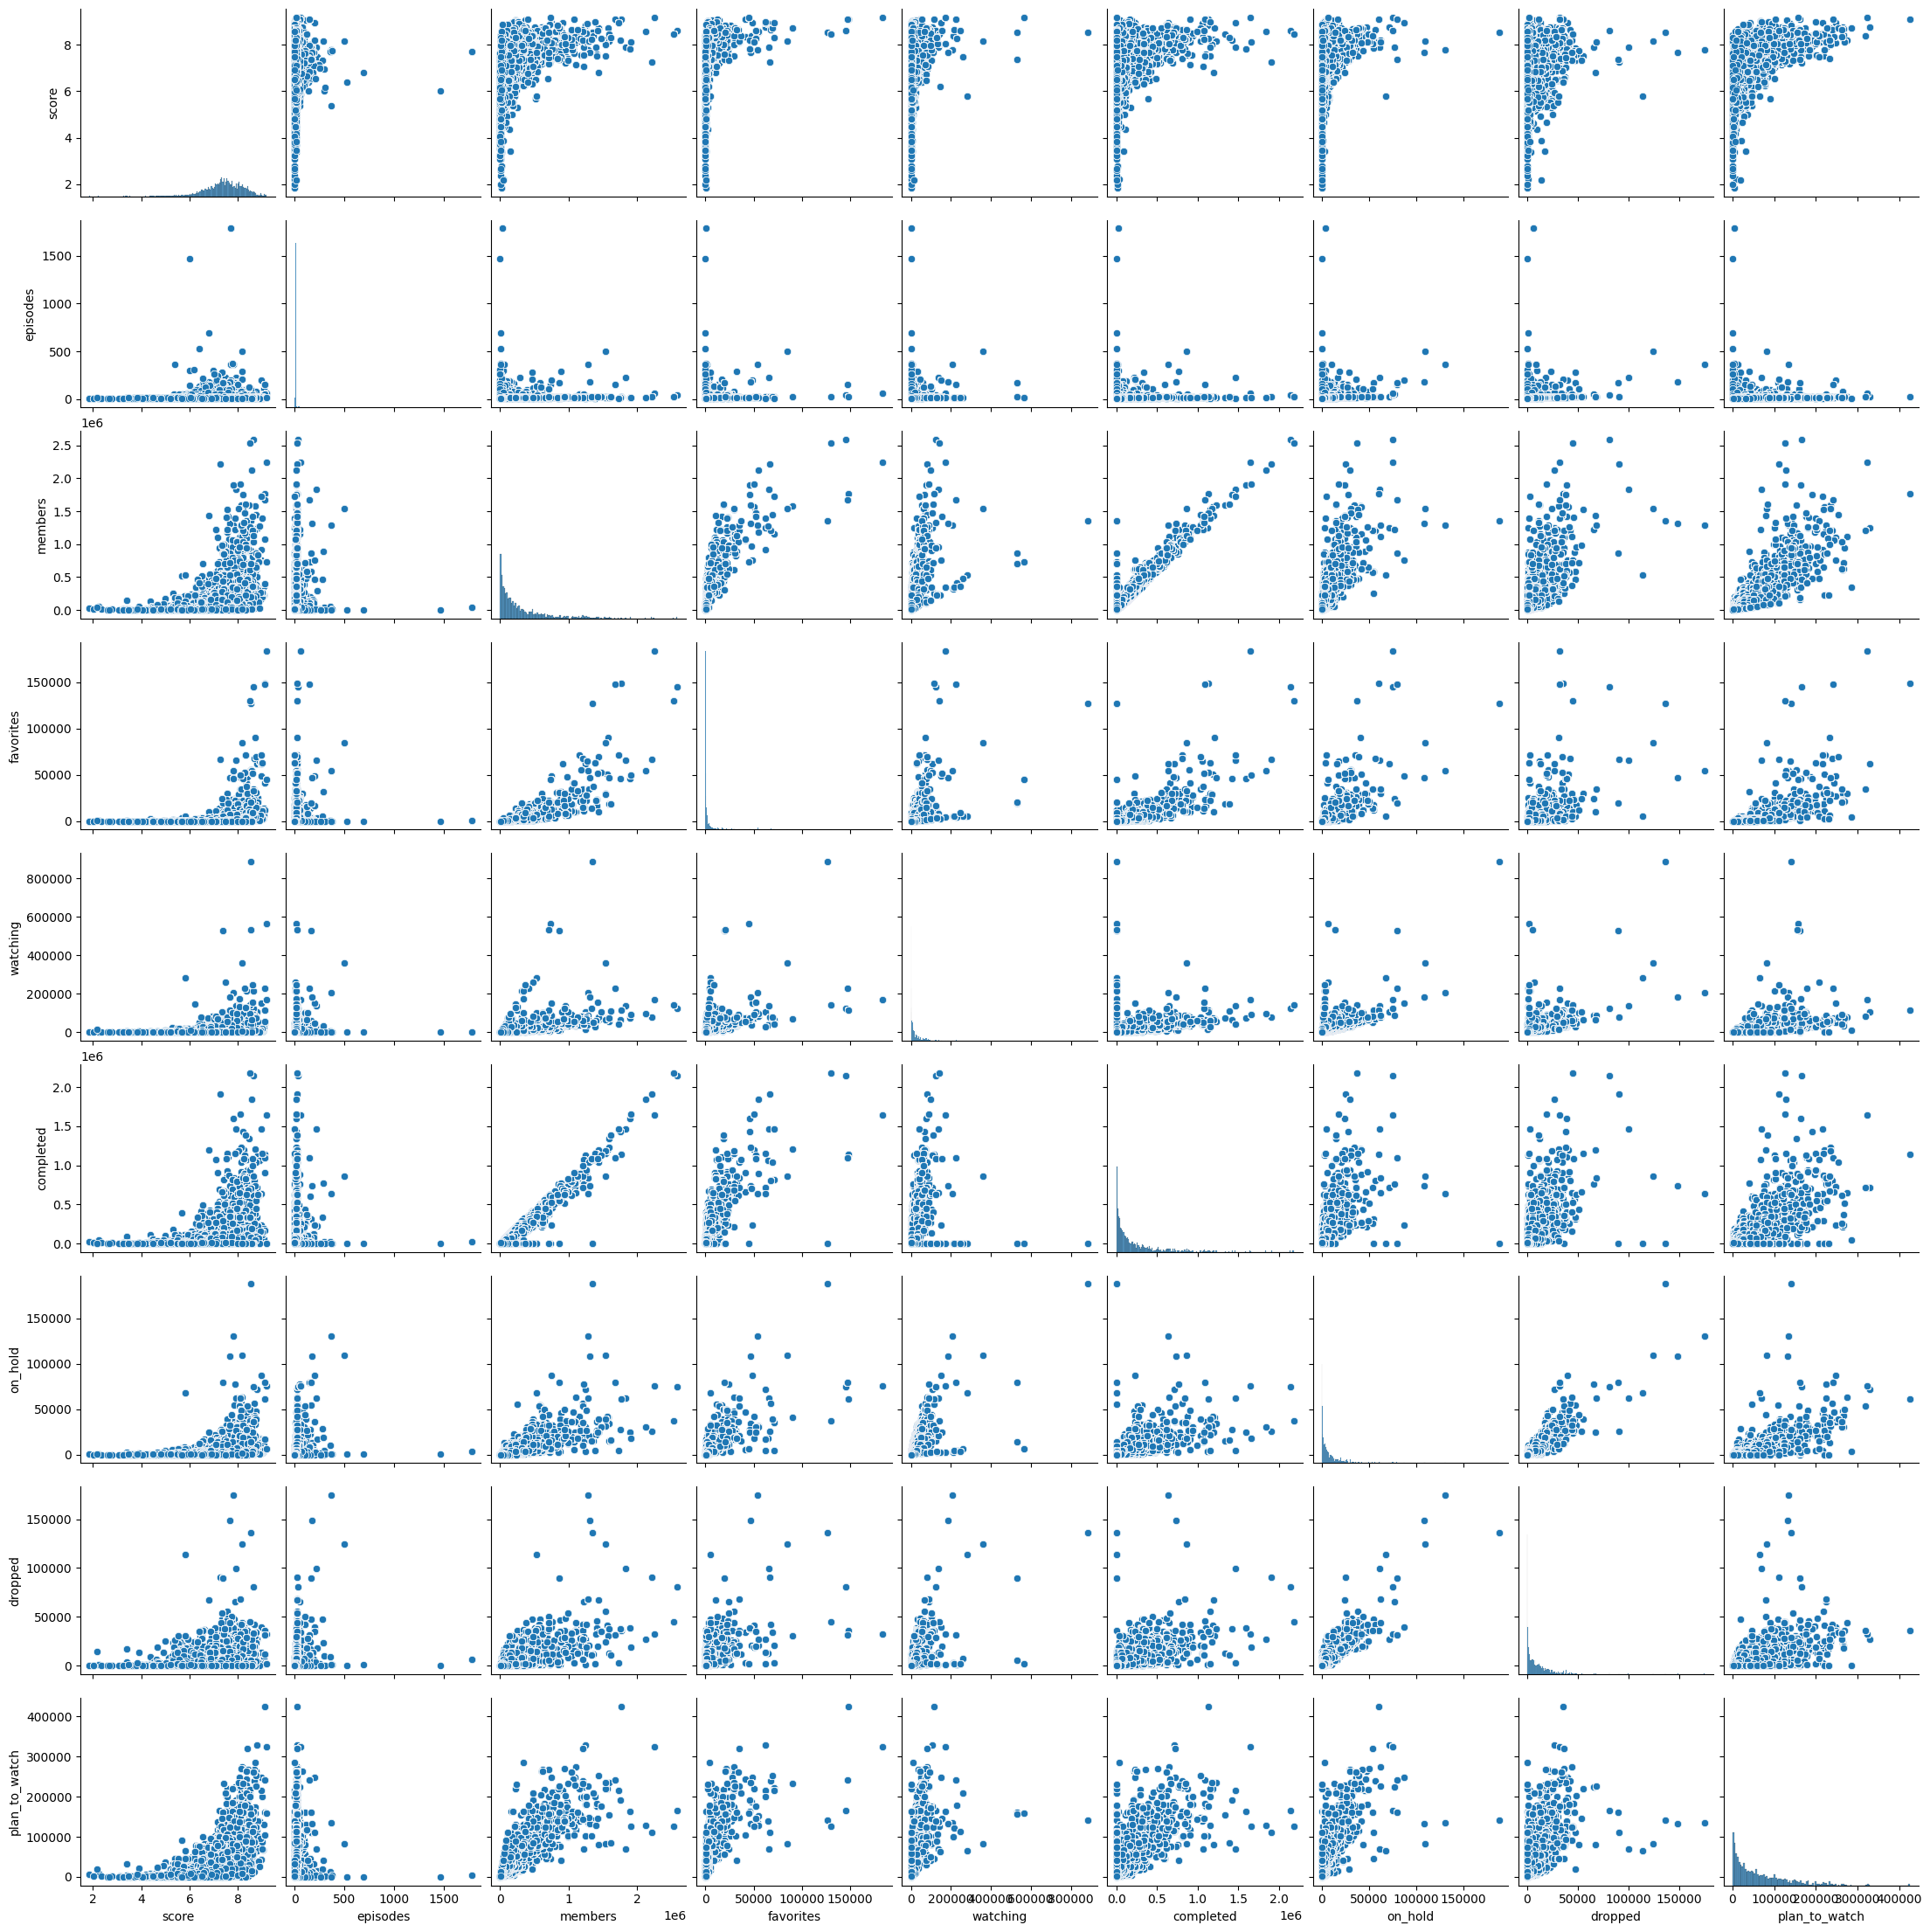

In [ ]:
numeric_cols = [
    'score',
    'episodes',
    'members',
    'favorites',
    'watching',
    'completed',
    'on_hold',
    'dropped',
    'plan_to_watch'
]

categorical_cols = [
    
]
# Categorical columns
#categorical_cols = anime_formatted.select_dtypes(
#    include=["object", "category", "bool"]
#).columns.tolist()

# Pairplot
g = sns.pairplot(
    anime_formatted,
    vars=numeric_cols
)

plt.show()

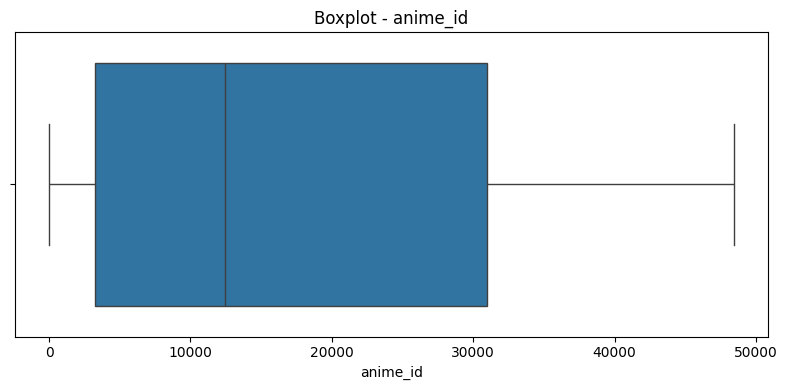

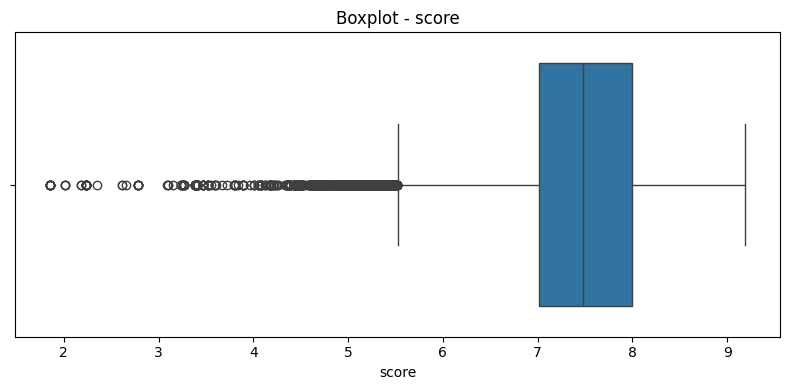

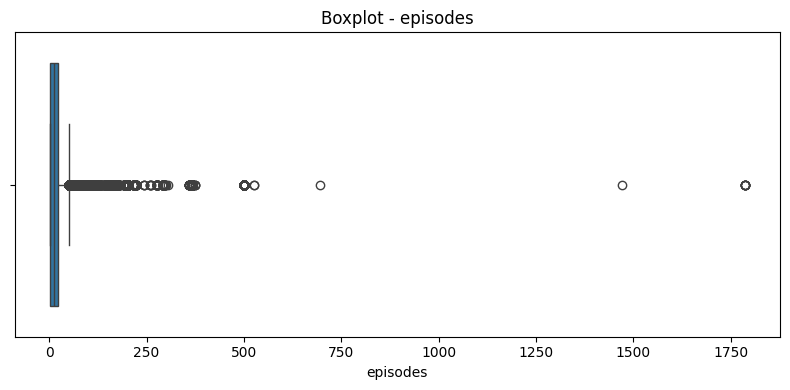

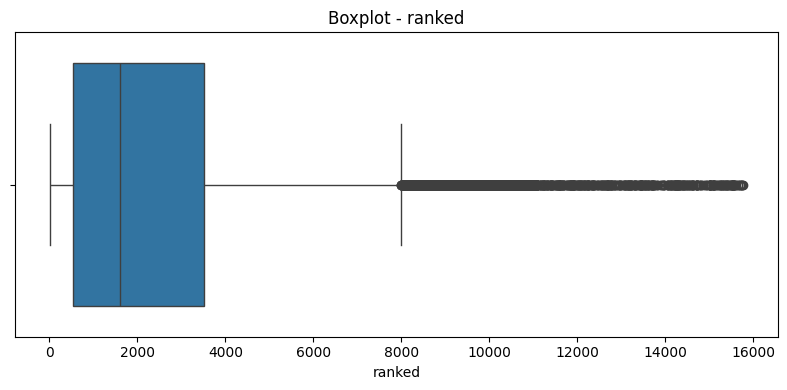

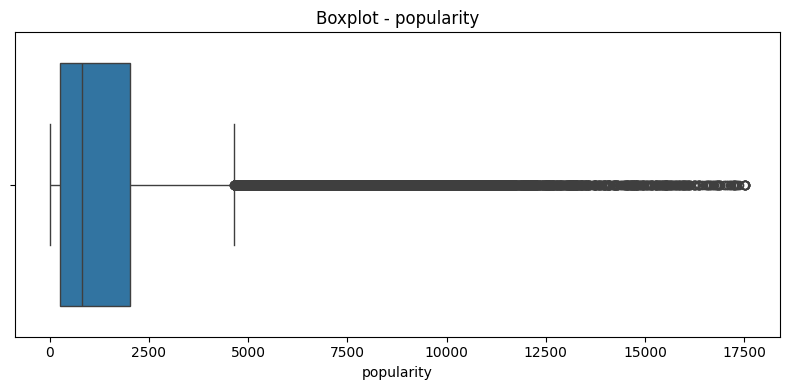

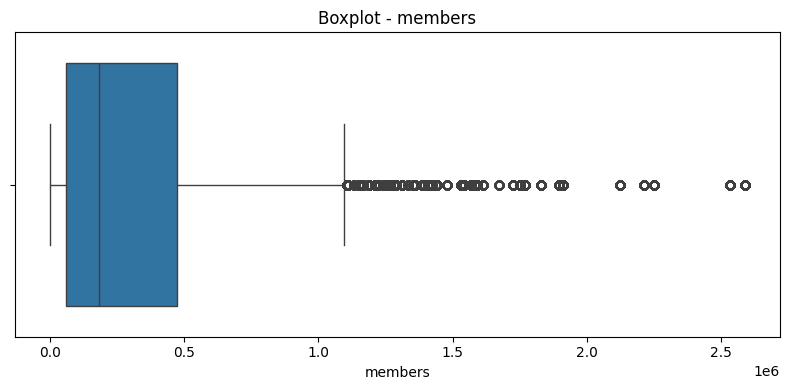

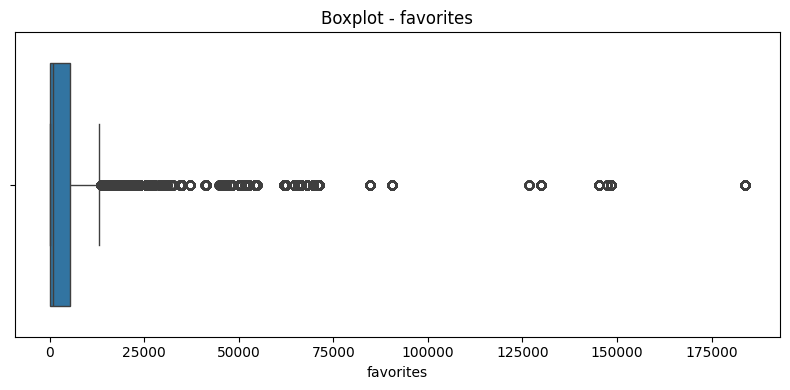

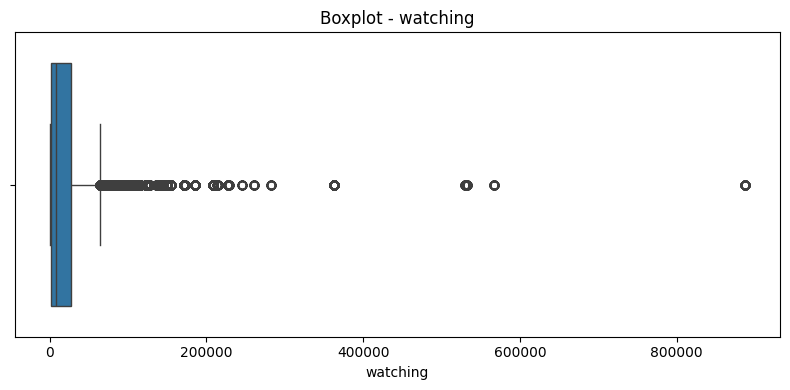

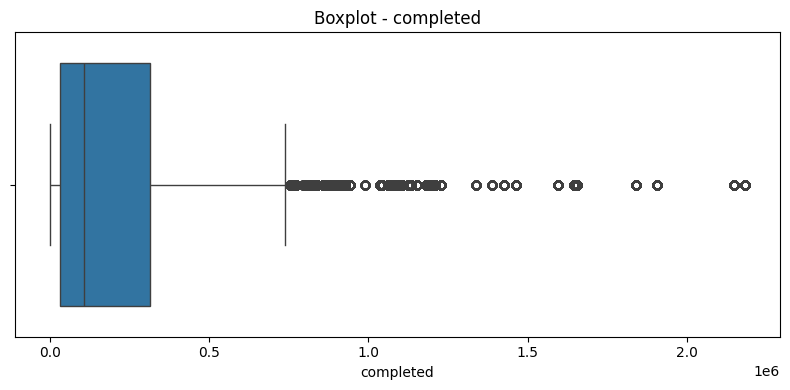

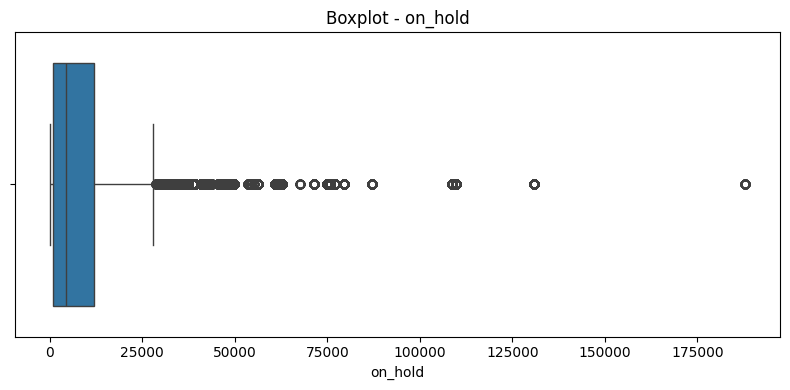

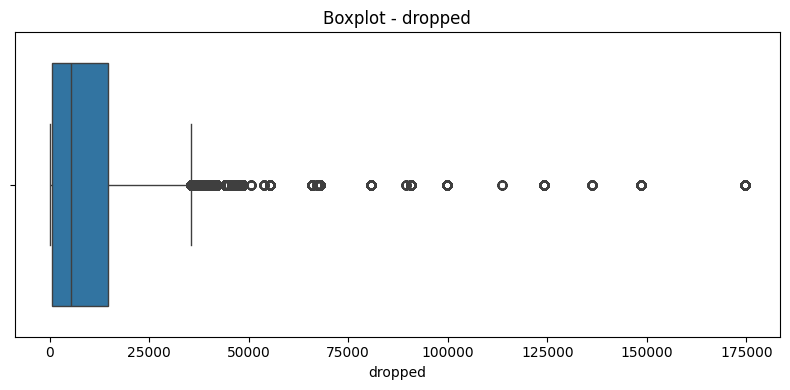

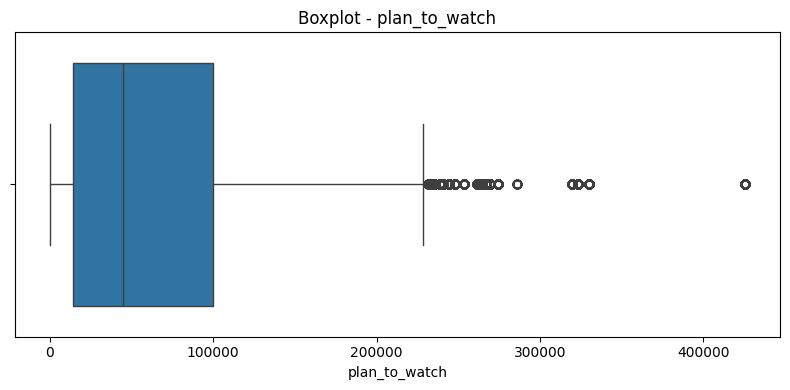

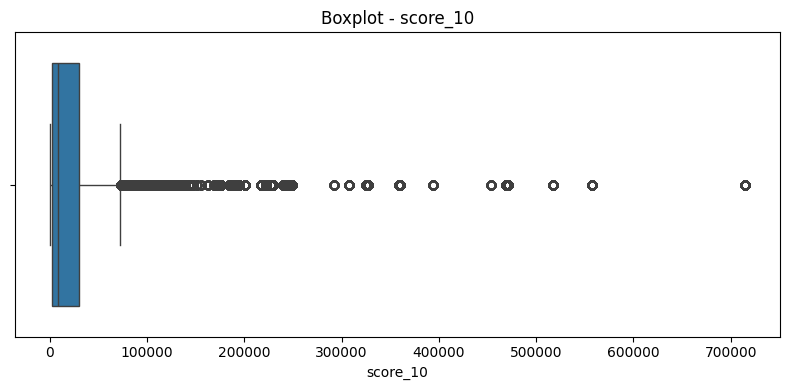

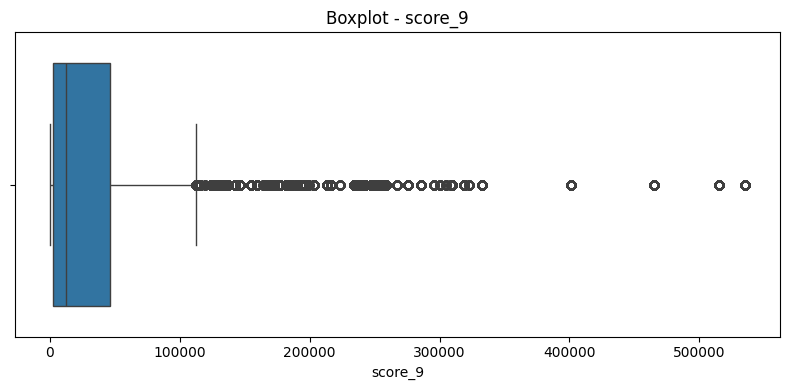

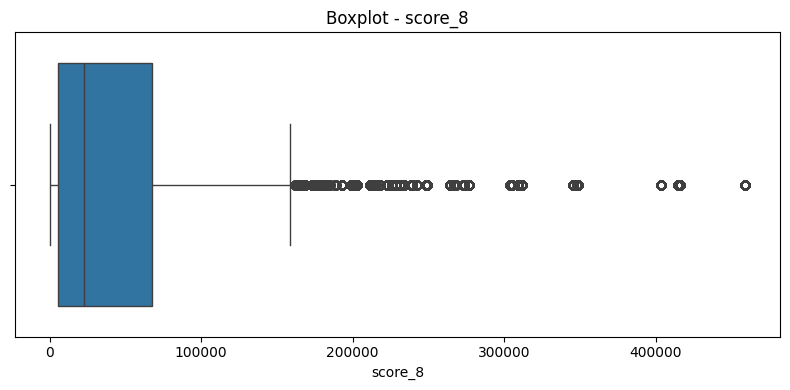

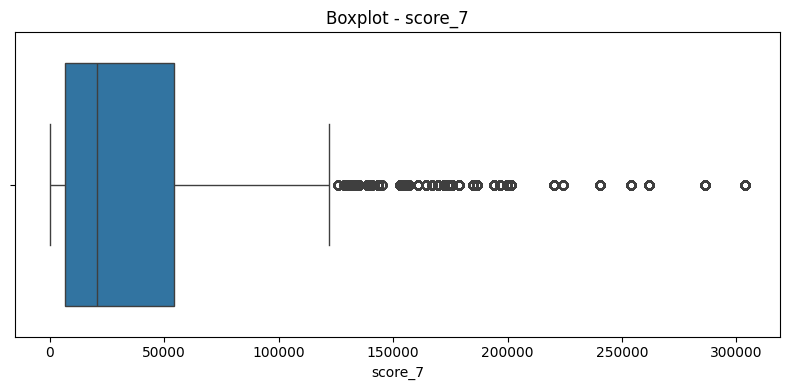

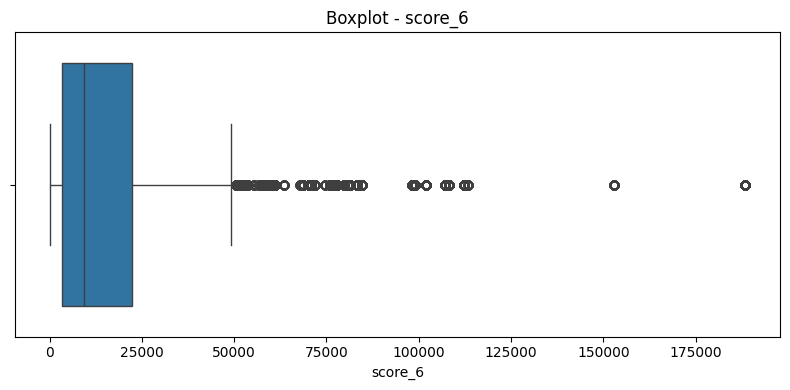

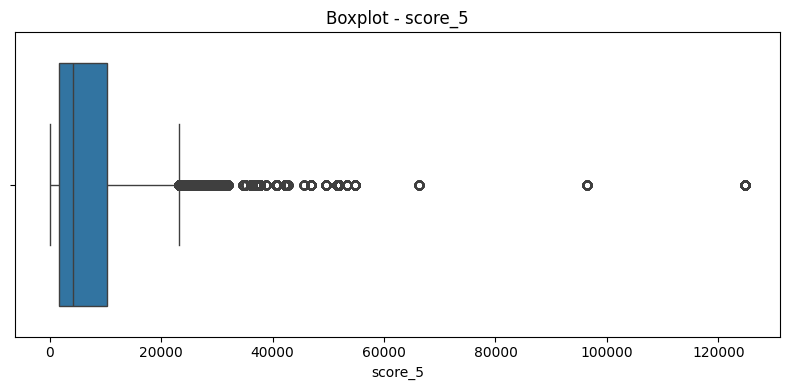

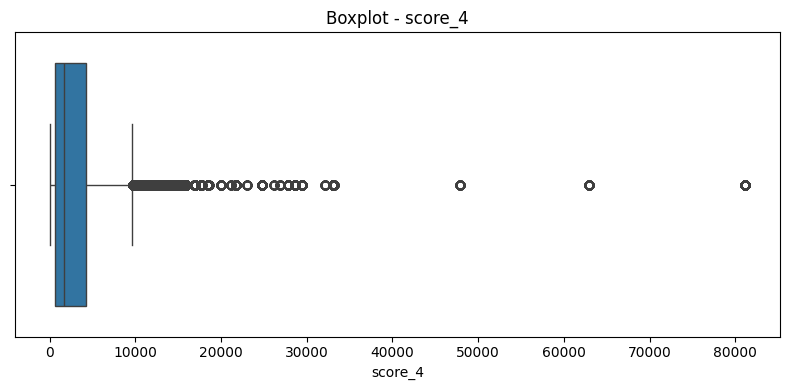

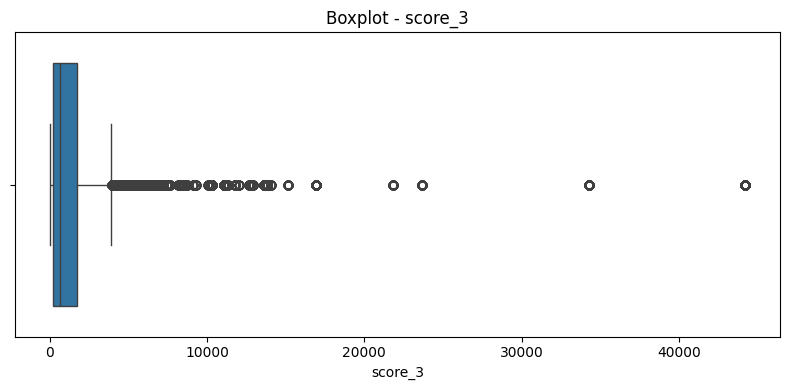

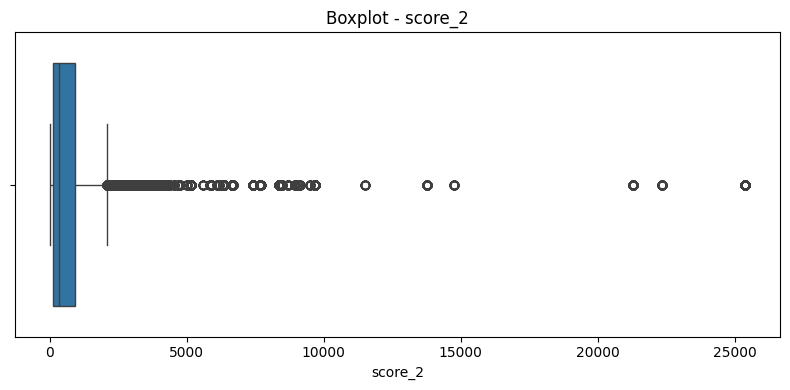

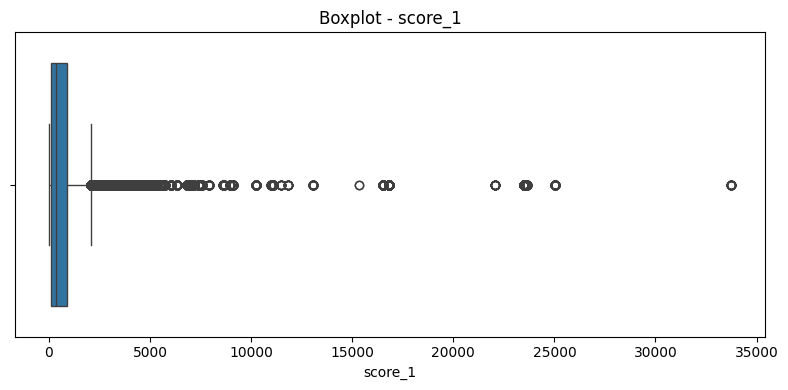

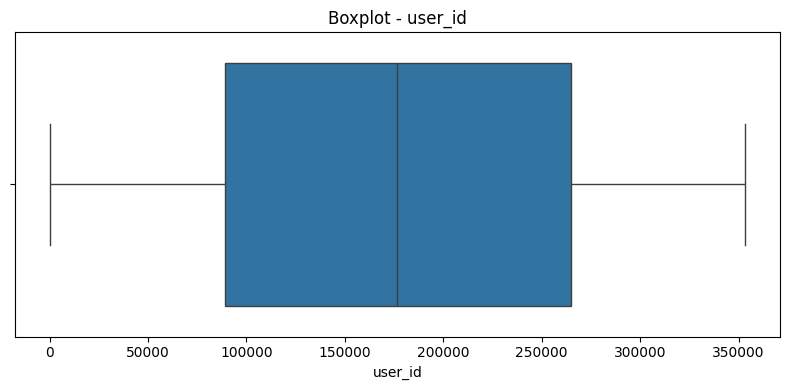

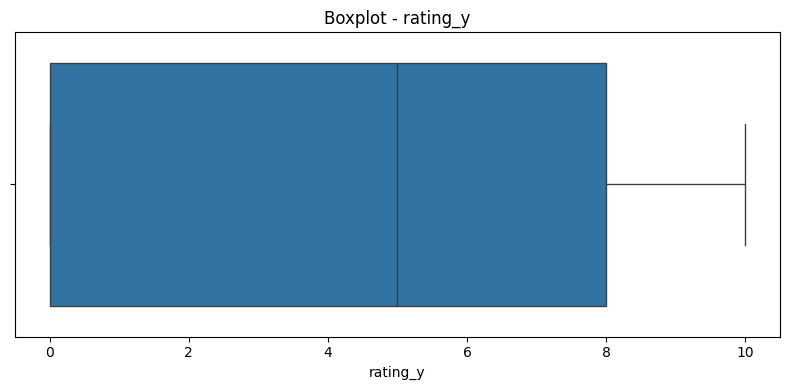

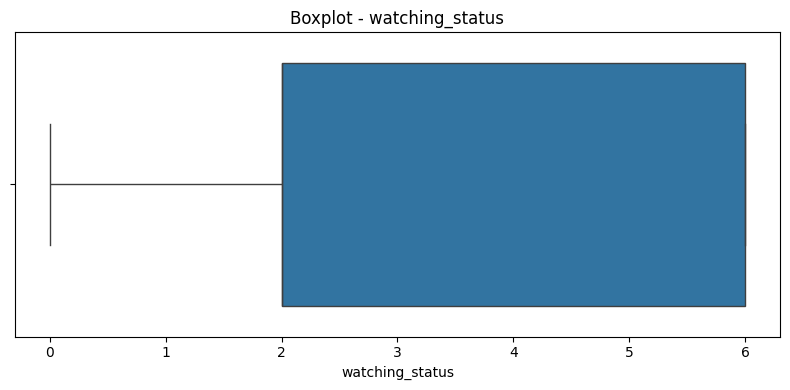

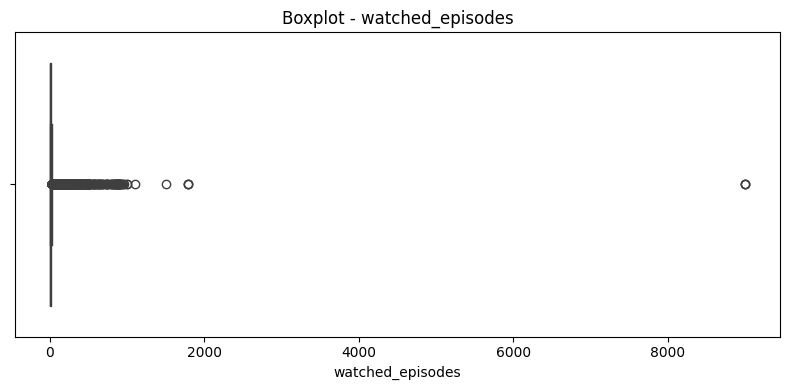

C:\Users\aline\AppData\Local\Temp\ipykernel_28144\1296687153.py:35: UserWarning: Glyph 65343 (\N{FULLWIDTH LOW LINE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\aline\AppData\Local\Temp\ipykernel_28144\1296687153.py:35: UserWarning: Glyph 65290 (\N{FULLWIDTH ASTERISK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\aline\AppData\Local\Temp\ipykernel_28144\1296687153.py:35: UserWarning: Glyph 65291 (\N{FULLWIDTH PLUS SIGN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\aline\AppData\Local\Temp\ipykernel_28144\1296687153.py:35: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()
C:\Users\aline\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 65343 (\N{FULLWIDTH LOW LINE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\aline\AppData\Roaming\Python\Py

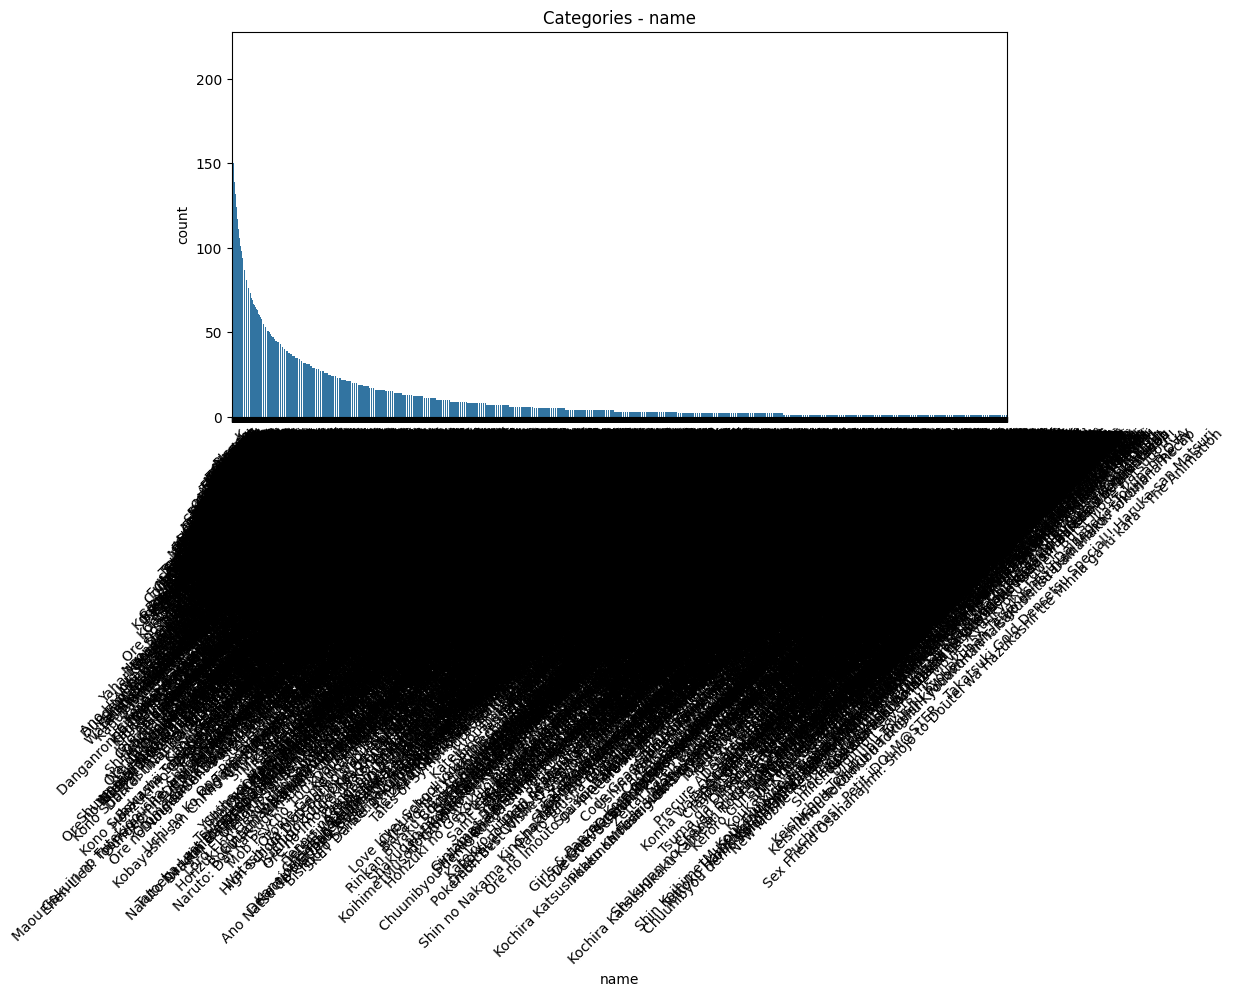

C:\Users\aline\AppData\Local\Temp\ipykernel_28144\1296687153.py:35: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


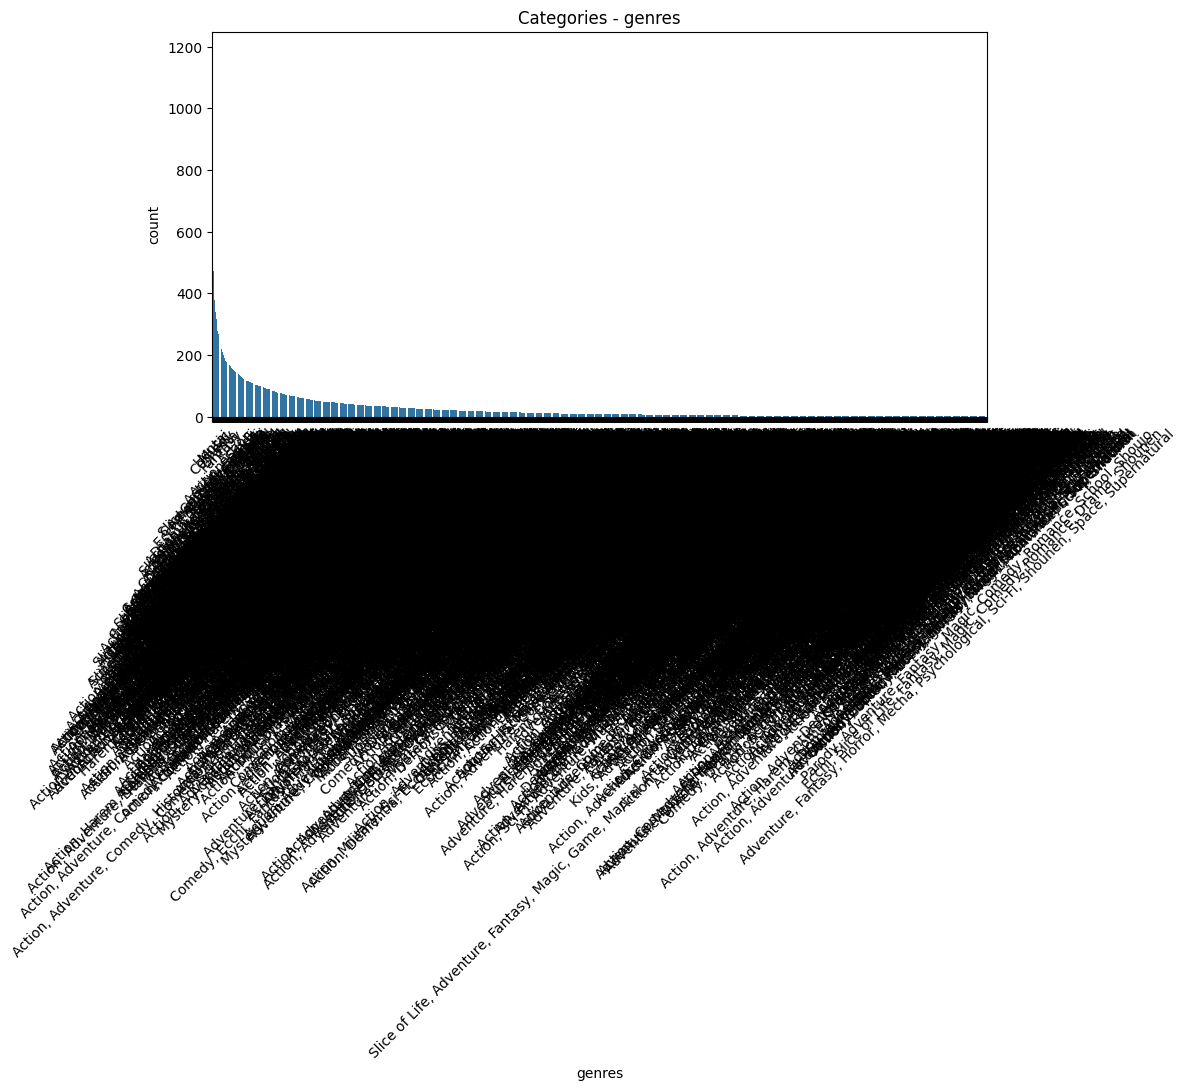

In [ ]:
def plot_dataframe(df):
    # Numeric columns
    numeric_cols = df.select_dtypes(include=["number"]).columns

    # Categorical columns
    categorical_cols = df.select_dtypes(
        include=["object", "category", "bool"]
    ).columns

    # ---------- BOXPLOTS ----------
    for col in numeric_cols:
        plt.figure(figsize=(8, 4))
        
        sns.boxplot(x=df[col])
        
        plt.title(f"Boxplot - {col}")
        plt.xlabel(col)
        plt.tight_layout()
        plt.show()

    # ---------- HISTOGRAMS / COUNTPLOTS ----------
    for col in categorical_cols:
        plt.figure(figsize=(10, 5))
        
        order = df[col].value_counts().index
        
        sns.countplot(
            data=df,
            x=col,
            order=order
        )
        
        plt.title(f"Categories - {col}")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()
        
plot_dataframe(anime_formatted)